In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import h5py
import numpy as np
import class_utils as class_utils
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker

## the spectral density results [to be updated] ##

## Compute the continuum ##

In [3]:

config_path = "config.yml" 

output_dir = class_utils.create_output_dir()

config = class_utils.read_config(config_path)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
UIB = config["physics"]["UIB"]
M = Lx * Ly

dJUs = np.linspace(**config["lists"]["dJUs"])
muU = eval(config["physics"]["muU"])

UIB = config["physics"]["UIB"]
cutoff = config["physics"]["cutoff"]
dJUs = np.linspace(**config["lists"]["dJUs"])

grid = Grid(Lx, Ly)

epss = np.zeros((len(dJUs), M * N))
omegs = np.zeros((len(dJUs), M * N))
epss_mat = np.zeros((len(dJUs), M * N , M * N))
omega_mat = np.zeros((len(dJUs), M * N, M * N))
pertE = np.zeros(len(dJUs))
dJUs_rep = np.zeros((len(dJUs), M * N))
for dJU_ind in range(0, len(dJUs)):
    dJU = dJUs[dJU_ind]
    print(dJU)
    params = Params(N, dJU, muU, UIB, cutoff)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)

    # the rayleigh schrodinger result
    pert = perturbative(grid, params, verts, omegaklambda)
    Pert_Energy = pert.perturbative_energy(n0)
    pertE[dJU_ind] = Pert_Energy[0] + Pert_Energy[1] + Pert_Energy[2]

    Epol = 0
    self_energy = Self_Energy(Epol, grid, params, verts, omegaklambda)
    omegs[dJU_ind, :] = self_energy.omega_vec()
    epss[dJU_ind, :] = dJU * self_energy.epsI_vec()
    dJUs_rep[dJU_ind, :] = np.ones(Lx * Ly * N) * dJU

    # the 2-excitation, 1 impurity continuum
    # the 0th row and 0th column are to be discarded as they describe 1-excitation 1 impurity continuua.
    omega_mat[dJU_ind, :, :] = self_energy.omega_vec()[:, np.newaxis] + self_energy.omega_vec()[np.newaxis, :]
    epss_mat[dJU_ind, :, :]  = dJU * self_energy.eps_grid()
    
continuum = omegs + epss
continuum_2p = omega_mat + epss_mat


0.0


ValueError: could not broadcast input array from shape (196,) into shape (343,)

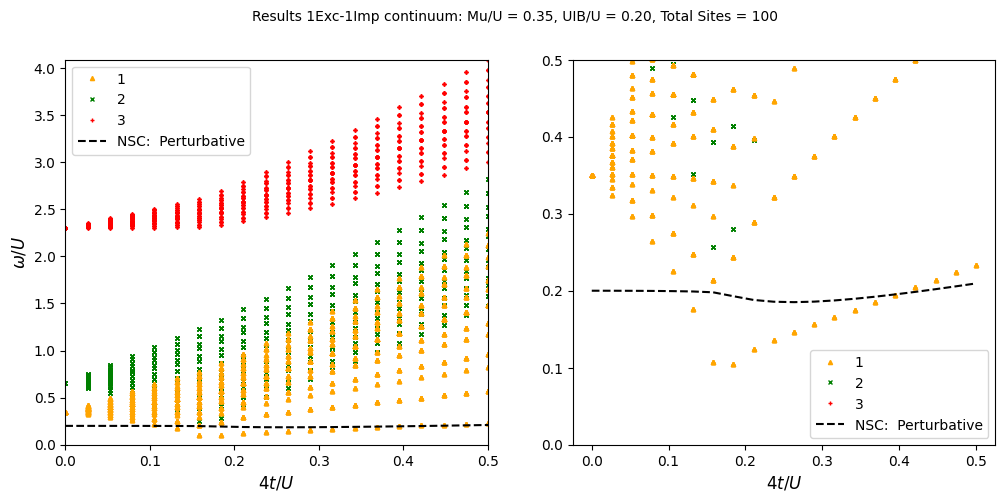

In [18]:
## 1 excitation - 1 impurity continuua
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12,5))

msize = 3
for dJU_ind in range(0, len(dJUs)):
    if dJU_ind == 0:
        ax1.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, M], '^', color="orange", markersize = msize, label = "1")
        ax1.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, 2*M], 'x', color="green",markersize = msize, label = "2")
        ax1.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, 3*M], '+', color="red", markersize = msize, label = "3")
        ax2.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, M], '^', color="orange", markersize = msize, label = "1")
        ax2.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, 2*M], 'x', color="green",markersize = msize, label = "2")
        ax2.plot(dJUs_rep[dJU_ind, 2*M], continuum[dJU_ind, 3*M], '+', color="red", markersize = msize, label = "3")    
    
    ax1.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, 2*M: 3*M ], 'x', color="green",markersize = msize)
    ax1.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, M: 2*M ], '^', color="orange", markersize = msize)
    ax1.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, 3*M: 4*M ], '+', color="red", markersize = msize)
    ax2.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, 2*M: 3*M ], 'x', color="green",markersize = msize)
    ax2.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, M: 2*M ], '^', color="orange", markersize = msize)
    ax2.plot(dJUs_rep[dJU_ind, 2*M : 3*M], continuum[dJU_ind, 3*M: 4*M ], '+', color="red", markersize = msize)

ax1.set_xlabel(r'$4t/U$', fontsize=12)
ax2.set_xlabel(r'$4t/U$', fontsize=12)
ax1.set_ylabel(r'$\omega/U$', fontsize=12)


ax1.plot(dJUs, pertE, linestyle='--', label='NSC:  Perturbative', color='black', linewidth=1.5)
ax2.plot(dJUs, pertE, linestyle='--', label='NSC:  Perturbative', color='black', linewidth=1.5)
fig.suptitle(f"Results 1Exc-1Imp continuum: Mu/U = {muU:0.2f}, UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 10)
ax1.set_ylim(np.min(continuum[:,:4*M]), np.max(continuum[:,:4*M]))
ax2.set_ylim(0, 0.5)
ax1.set_xlim(min(dJUs), max(dJUs))
ax1.legend()
ax2.legend()
plt.show()


In [19]:
## Save the figure 
filename = f'../figs/Continuum/UIB_{UIB:.2f}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_dJU_{len(dJUs)}.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')

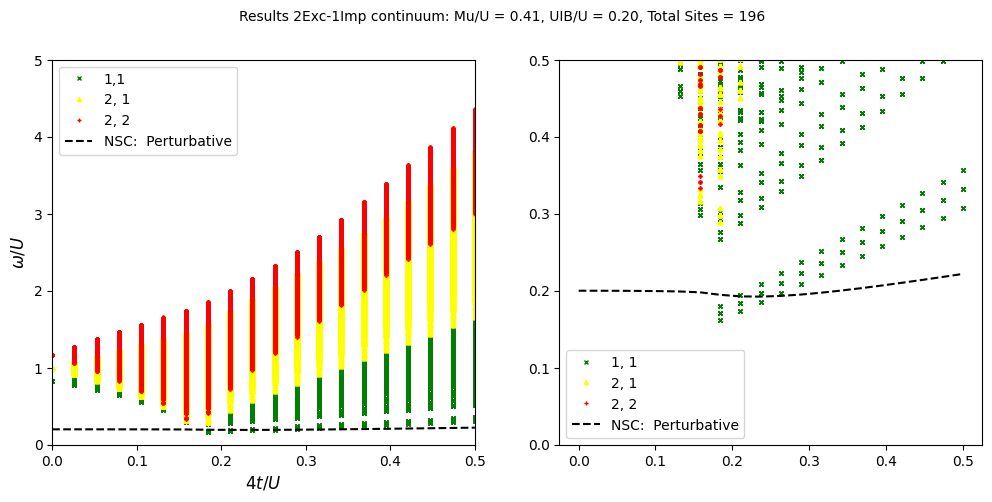

In [25]:
## 1 excitation - 1 impurity continuua
fig, (ax1,ax2) = plt.subplots(ncols = 2, figsize = (12,5))

msize = 3
for dJU_ind in range(0, len(dJUs)):
    if dJU_ind == 0:
        ax1.plot(dJUs_rep[dJU_ind, M], continuum_2p[dJU_ind, M, M ], 'x', color="green",markersize = msize, label = '1,1')
        ax1.plot(dJUs_rep[dJU_ind, M], continuum_2p[dJU_ind, M, 2*M ], '^', color="yellow",markersize = msize, label = '2, 1')
        ax1.plot(dJUs_rep[dJU_ind, M], continuum_2p[dJU_ind, 2*M, 2*M ], '+', color="red",markersize = msize, label = '2, 2')
        ax2.plot(dJUs_rep[dJU_ind, M], continuum_2p[dJU_ind, M, M ], 'x', color="green",markersize = msize, label = '1, 1')
        ax2.plot(dJUs_rep[dJU_ind, M], continuum_2p[dJU_ind, M, 2*M ], '^', color="yellow",markersize = msize, label = '2, 1')
        ax2.plot(dJUs_rep[dJU_ind, M], continuum_2p[dJU_ind, 2*M, 2*M ], '+', color="red",markersize = msize, label = '2, 2')
        
    ax1.plot(dJUs_rep[dJU_ind, M : 2*M], continuum_2p[dJU_ind, M: 2*M, M: 2*M ], 'x', color="green",markersize = msize)
    ax1.plot(dJUs_rep[dJU_ind, M : 2*M], continuum_2p[dJU_ind, M: 2*M, 2*M: 3*M ], '^', color="yellow",markersize = msize)
    ax1.plot(dJUs_rep[dJU_ind, M : 2*M], continuum_2p[dJU_ind, 2*M: 3*M, 2*M: 3*M ], '+', color="red",markersize = msize)
    ax2.plot(dJUs_rep[dJU_ind, M : 2*M], continuum_2p[dJU_ind, M: 2*M, M: 2*M ], 'x', color="green",markersize = msize)
    ax2.plot(dJUs_rep[dJU_ind, M : 2*M], continuum_2p[dJU_ind, M: 2*M, 2*M: 3*M ], '^', color="yellow",markersize = msize)
    ax2.plot(dJUs_rep[dJU_ind, M : 2*M], continuum_2p[dJU_ind, 2*M: 3*M, 2*M: 3*M ], '+', color="red",markersize = msize)
    
        

ax1.set_xlabel(r'$4t/U$', fontsize=12)
#ax2.set_xlabel(r'$4t/U$', fontsize=12)
ax1.set_ylabel(r'$\omega/U$', fontsize=12)


ax1.plot(dJUs, pertE, linestyle='--', label='NSC:  Perturbative', color='black', linewidth=1.5)
ax2.plot(dJUs, pertE, linestyle='--', label='NSC:  Perturbative', color='black', linewidth=1.5)
fig.suptitle(f"Results 2Exc-1Imp continuum: Mu/U = {muU:0.2f}, UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 10)
ax1.set_ylim(0,5)
ax2.set_ylim(0,0.5)
#ax2.set_ylim(0, 1)
ax1.set_xlim(min(dJUs), max(dJUs))
ax1.legend()
ax2.legend()
plt.show()


In [26]:
## Save the figure 
filename = f'../figs/Continuum/2p_UIB_{UIB:.2f}__Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_dJU_{len(dJUs)}.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')